In [65]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report , confusion_matrix
from sklearn import tree
from sklearn.tree import plot_tree
from sklearn import tree
import matplotlib.pyplot as plt

In [66]:
df = pd.read_csv(r"C:\Users\MEPZ\OneDrive\Desktop\Sowndharya_A\Week_4\anaconda_projects\golf.csv")
df

,Outlook,Temperature,Humidity,Wind,PlayTennis
0,Rainy,Hot,High,True,No
1,Overcast,Hot,High,False,Yes
2,Sunny,Mild,High,False,Yes
3,Sunny,Cool,Normal,False,Yes
4,Sunny,Cool,Normal,True,No
5,Overcast,Cool,Normal,True,Yes
6,Rainy,Mild,High,False,No
7,Rainy,Cool,Normal,False,Yes
8,Sunny,Mild,Normal,False,Yes
9,Rainy,Mild,Normal,True,Yes


In [67]:
model = DecisionTreeClassifier()

In [68]:
df.describe()

,Outlook,Temperature,Humidity,Wind,PlayTennis
count,13,13,13,13,13
unique,3,3,2,2,2
top,Sunny,Mild,Normal,False,Yes
freq,5,6,7,7,9


In [69]:
df= pd.get_dummies(df, columns=["Outlook","Temperature","Humidity","Wind"],dtype=int)
df.head()

,PlayTennis,Outlook_Overcast,Outlook_Rainy,Outlook_Sunny,Temperature_Cool,Temperature_Hot,Temperature_Mild,Humidity_High,Humidity_Normal,Wind_False,Wind_True
0,No,0,1,0,0,1,0,1,0,0,1
1,Yes,1,0,0,0,1,0,1,0,1,0
2,Yes,0,0,1,0,0,1,1,0,1,0
3,Yes,0,0,1,1,0,0,0,1,1,0
4,No,0,0,1,1,0,0,0,1,0,1


In [70]:
X = df[[
"Outlook_Overcast","Outlook_Rainy","Outlook_Sunny",
"Temperature_Cool","Temperature_Hot","Temperature_Mild",
"Humidity_High","Humidity_Normal",
"Wind_False","Wind_True"
]]

y = df["PlayTennis"]
features = ["Outlook_Overcast","Outlook_Rainy","Outlook_Sunny",
"Temperature_Cool","Temperature_Hot","Temperature_Mild",
"Humidity_High","Humidity_Normal",
"Wind_False","Wind_True"]

In [71]:
model = DecisionTreeClassifier()
model.fit(X,y)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


[Text(0.6, 0.9, 'Outlook_Overcast <= 0.5\ngini = 0.426\nsamples = 13\nvalue = [4, 9]'),
 Text(0.5, 0.7, 'Humidity_High <= 0.5\ngini = 0.494\nsamples = 9\nvalue = [4, 5]'),
 Text(0.55, 0.8, 'True  '),
 Text(0.3, 0.5, 'Wind_False <= 0.5\ngini = 0.32\nsamples = 5\nvalue = [1, 4]'),
 Text(0.2, 0.3, 'Outlook_Sunny <= 0.5\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.1, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.3, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.4, 0.3, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.7, 0.5, 'Outlook_Sunny <= 0.5\ngini = 0.375\nsamples = 4\nvalue = [3, 1]'),
 Text(0.6, 0.3, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.8, 0.3, 'Wind_True <= 0.5\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.7, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.9, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.7, 0.7, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.6499999999999999, 0.8, '  False')]

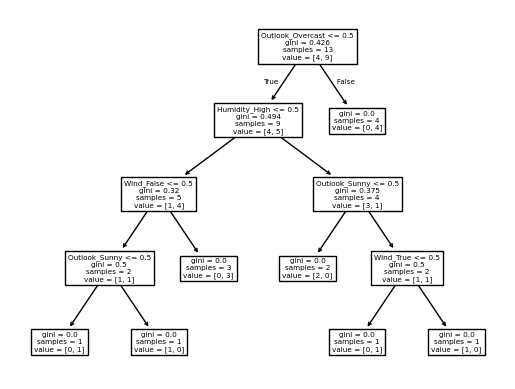

In [76]:
tree.plot_tree(model,feature_names=features)

voting

from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score

X, y = make_moons(n_samples=500, noise=0.30)
X_train, X_test, y_train, y_test = train_test_split(X, y)


# created LR model
log = LogisticRegression()
# created RF model
rnd = RandomForestClassifier(n_estimators=100)
# created SVC model
svm = SVC(kernel="linear")

# array of models
voting = VotingClassifier(
    estimators=[('logistics_regression', log), ('random_forest', rnd), ('support_vector_machine', svm)],
    voting='hard')

voting.fit(X_train, y_train)

for clf in (log, rnd, svm, voting):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print(clf.__class__.__name__, accuracy_score(y_test, y_pred))





Bagging

In [78]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score



X, y = make_moons(n_samples=500, noise=0.30)

X_train, X_test, y_train, y_test = train_test_split(X, y)

#For regression, you can use BaggingRegressors

bagging_clf = BaggingClassifier(
    DecisionTreeClassifier(), n_estimators=250,
    max_samples=100, bootstrap=True, random_state=101)


bagging_clf.fit(X_train, y_train)
y_pred = bagging_clf.predict(X_test)
print("ACC = ",accuracy_score(y_test, y_pred))
print("SCORE = ",bagging_clf.oob_score)



ACC =  0.904
SCORE =  False


Boosting

In [82]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

X, y = make_moons(n_samples=500, noise=0.30)
X_train, X_test, y_train, y_test = train_test_split(X, y)

adaboost_clf = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=1), n_estimators=200,
    algorithm="SAMME", learning_rate=0.5, random_state=42)

adaboost_clf.fit(X_train, y_train)

y_pred = adaboost_clf.predict(X_test)
print("ACCURACY = ",accuracy_score(y_test, y_pred))

C:\Users\MEPZ\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


ACCURACY =  0.912
